# Simple fibril model parameter sweeps

## Notebook setup

### Imports

In [3]:
# Imports
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import open3d as o3d
from scipy.spatial.transform import Rotation as R
from tqdm import tqdm
import sys
import json
from itertools import product
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from collections import defaultdict

# from custom_fibril_gen_v2 import *
# from nrss_fibril_functions_v2 import *

sys.path.append('/Users/andrew/Library/CloudStorage/OneDrive-UCB-O365/research/data_analysis/rsoxs_suite/morph_gen/custom_fibril_gen')
from custom_fibril_gen_v2 import *

### Define Paths

In [4]:
# notebookPath = pathlib.Path.cwd()
# savePath = notebookPath.joinpath('simple_fibril_sweeps_outputs')
# # fibrilsPath = basePath.joinpath('custom_fibril_gen', f'fixed_fibrils')

basePath = pathlib.Path('/Users/andrew/Library/CloudStorage/OneDrive-UCB-O365/research/data_analysis/rsoxs_suite/morph_gen')
savePath = basePath.joinpath('simple_fibril_open3d_outputs')


In [5]:
savePath.exists()

True

## Functions

In [ ]:
# # Define functions
# def mol_orient(scenario, rotated_bb_coords, rotated_bb_axs, rotated_bb_css, rotated_fibril, set_theta):
#     """
#     Assigns ZY Euler orientation angles (psi, theta) for molecular extraordinary axes
#     in different alignment scenarios relative to the local fibril axis.

#     Parameters:
#     - scenario: str
#         Molecular extraordinary axis orientation scenario identifier:
#           A = Type II (para. to long axis): theta=long_axis_theta, psi=long_axis_psi
#           B = Custom  (indp. to long axis): Set declination; theta=set_theta,  psi=long_axis_psi+90°
#           C = Type I  (perp. to long axis): Radial; always point away from center of fibril cross sections         
#           D = Type I  (perp. to long axis): Random; always point in the plane of the fibril cross sections
#     - rotated_bb_coords: (N, 3) np.ndarray
#         Backbone centerline positions along fibril long axis after rotation
#     - rotated_bb_axs: (N, 3) np.ndarray
#         Backbone axial unit vectors (long axis) after rotation
#     - rotated_bb_css: (N, 2, 3) np.ndarray
#         Backbone short-axis vectors (cross-sectional frame, 2 vectors per backbone point)
#     - rotated_fibril: (M, 3) np.ndarray
#         3D fibril coordinate positions (Å)
#     - set_theta: int or float
#         Used in Scenario B to specify declination angle

#     Returns:
#     - fibril_ZYrots: (M, 2) np.ndarray
#         Euler ZY rotation angles in degrees (psi ∈ [0,360), theta ∈ [0,180]) per fibril point in degrees
#     """
#     M = rotated_fibril.shape[0]
#     fibril_ZYrots = np.zeros((M, 2))
#     rng = np.random.default_rng()

#     if scenario == 'A':
#         psi = np.rad2deg(np.arctan2(rotated_bb_axs[:, 1], rotated_bb_axs[:, 0])) % 360
#         theta = np.rad2deg(np.arccos(rotated_bb_axs[:, 2])) % 180
#         euler_ZY_rot = np.vstack((psi, theta)).T
#         for i, fibril_point in enumerate(rotated_fibril):
#             d = np.linalg.norm(rotated_bb_coords - fibril_point, axis=1)
#             idx = np.argmin(d)
#             fibril_ZYrots[i] = euler_ZY_rot[idx]
            
#     elif scenario == 'B':
#         for i, fibril_point in enumerate(rotated_fibril):
#             d = np.linalg.norm(rotated_bb_coords - fibril_point, axis=1)
#             idx = np.argmin(d)
#             axis_vec = rotated_bb_axs[idx]
#             psi = (np.rad2deg(np.arctan2(axis_vec[1], axis_vec[0])) + 90) % 360
#             fibril_ZYrots[i] = [psi, set_theta]
    
#     elif scenario == 'C': 
#         for i, fibril_point in enumerate(rotated_fibril):
#             bb_displacements = rotated_bb_coords - fibril_point
#             bb_distances = np.linalg.norm(bb_displacements, axis=1)
#             bb_min_idx = np.argmin(bb_distances)

#             min_displacement = bb_displacements[bb_min_idx]
#             orient_vec = -min_displacement / np.linalg.norm(min_displacement)

#             theta = np.rad2deg(np.arccos(orient_vec[2])) % 180
#             psi = np.rad2deg(np.arctan2(orient_vec[1], orient_vec[0])) % 360
#             fibril_ZYrots[i] = [psi, theta]

#     elif scenario == 'D': 
#         for i, fibril_point in enumerate(rotated_fibril):
#             dists = np.linalg.norm(rotated_bb_coords - fibril_point, axis=1)
#             idx = np.argmin(dists)

#             css1 = rotated_bb_css[0, idx]
#             css2 = rotated_bb_css[1, idx]

#             alpha = rng.uniform(0, 2 * np.pi)
#             orient_vec = np.cos(alpha) * css1 + np.sin(alpha) * css2
#             orient_vec = orient_vec / np.linalg.norm(orient_vec)

#             theta = np.rad2deg(np.arccos(orient_vec[2])) % 180
#             psi = np.rad2deg(np.arctan2(orient_vec[1], orient_vec[0])) % 360
#             fibril_ZYrots[i] = [psi, theta]
    
#     else:
#         raise ValueError(f"Unknown scenario '{scenario}'")

#     return fibril_ZYrots


In [39]:
def mol_orient_vectors(scenario, rotated_bb_coords, rotated_bb_axs, rotated_bb_css, rotated_fibril, set_theta):
    """
    Assigns molecular extraordinary axis vectors (unit vectors) for each fibril point based on orientation scenario.

    Orientation Scenarios:
    - A: Aligns orientation vector parallel to the local backbone long axis.
    - B: Rotates from the local backbone axis by a fixed angle (set_theta).
    - C: Points radially outward from the closest backbone centerline coordinate.
    - D: Selects a random direction within the cross-sectional plane.

    Parameters:
    - scenario: str
        Orientation scenario identifier (A, B, C, or D).
    - rotated_bb_coords: (N, 3) np.ndarray
        Backbone centerline coordinates after global rotation.
    - rotated_bb_axs: (N, 3) np.ndarray
        Local backbone long-axis unit vectors.
    - rotated_bb_css: (N, 2, 3) np.ndarray
        Short-axis cross-sectional unit vectors for each backbone point (2 per point).
    - rotated_fibril: (M, 3) np.ndarray
        Coordinates of points along the fibril for which orientations are needed.
    - set_theta: float
        Declination angle in degrees for scenario B.

    Returns:
    - fibril_vectors: (M, 3) np.ndarray
        Molecular orientation unit vectors (x, y, z) for each fibril point.
    """
    M = rotated_fibril.shape[0]  # number of fibril points
    fibril_vectors = np.zeros((M, 3))  # initialize output array
    rng = np.random.default_rng()  # random number generator for scenario D

    if scenario == 'A':
        # Orientation is aligned with local backbone long axis
        for i, fibril_point in enumerate(rotated_fibril):
            # Find nearest backbone point to fibril point
            d = np.linalg.norm(rotated_bb_coords - fibril_point, axis=1)
            idx = np.argmin(d)
            # Use its long-axis vector as orientation
            fibril_vectors[i] = rotated_bb_axs[idx]
            
    elif scenario == 'B':
        theta_rad = np.deg2rad(set_theta)
        for i, fibril_point in enumerate(rotated_fibril):
            d = np.linalg.norm(rotated_bb_coords - fibril_point, axis=1)
            idx = np.argmin(d)
            long_axis = rotated_bb_axs[idx]  # unit vector

            # Use XY projection of long_axis to compute psi + 90°
            psi_rad = np.arctan2(long_axis[1], long_axis[0]) + np.pi / 2

            # Spherical to Cartesian conversion with fixed theta and psi+90°
            x = np.sin(theta_rad) * np.cos(psi_rad)
            y = np.sin(theta_rad) * np.sin(psi_rad)
            z = np.cos(theta_rad)

            fibril_vectors[i] = np.array([x, y, z])
            
    # elif scenario == 'B':
    #     # Orientation is rotated from the backbone long axis by set_theta degrees
    #     theta_rad = np.deg2rad(set_theta)
    #     for i, fibril_point in enumerate(rotated_fibril):
    #         # Find nearest backbone point
    #         d = np.linalg.norm(rotated_bb_coords - fibril_point, axis=1)
    #         idx = np.argmin(d)
    #         long_axis_vec = rotated_bb_axs[idx]  # local backbone axis vector
    #         # Construct orthogonal vector to long_axis_vec
    #         ortho_vec = np.cross([0, 0, 1], long_axis_vec)  # try using z-axis
    #         if np.linalg.norm(ortho_vec) < 1e-6:
    #             ortho_vec = np.cross(long_axis_vec, [0, 1, 0])  # fallback if nearly parallel
    #         ortho_vec /= np.linalg.norm(ortho_vec)
    #         # Combine axis and orthogonal vector using the declination angle
    #         orient_vec = np.cos(theta_rad) * long_axis_vec + np.sin(theta_rad) * ortho_vec
    #         fibril_vectors[i] = orient_vec / np.linalg.norm(orient_vec)

    elif scenario == 'C':
        # Orientation points outward from fibril toward closest backbone point
        for i, fibril_point in enumerate(rotated_fibril):
            # Compute displacements from all backbone points
            bb_displacements = rotated_bb_coords - fibril_point
            bb_distances = np.linalg.norm(bb_displacements, axis=1)
            idx = np.argmin(bb_distances)
            # Vector pointing from fibril point to backbone (reversed)
            displacement = bb_displacements[idx]
            fibril_vectors[i] = -displacement / np.linalg.norm(displacement)

    elif scenario == 'D':
        # Orientation is random within the cross-sectional plane
        for i, fibril_point in enumerate(rotated_fibril):
            # Find nearest backbone point
            dists = np.linalg.norm(rotated_bb_coords - fibril_point, axis=1)
            idx = np.argmin(dists)
            # Get two orthogonal cross-sectional directions at that point
            css1 = rotated_bb_css[0, idx]  # short-axis vector 1
            css2 = rotated_bb_css[1, idx]  # short-axis vector 2
            # Choose a random linear combination of the two (unit circle)
            alpha = rng.uniform(0, 2 * np.pi)
            orient_vec = np.cos(alpha) * css1 + np.sin(alpha) * css2
            fibril_vectors[i] = orient_vec / np.linalg.norm(orient_vec)

    else:
        raise ValueError(f"Unknown scenario '{scenario}'")

    return fibril_vectors


def style_axes(ax, background, hide_all=True):
    if hide_all:
        ax.set_axis_off()
    else:
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")
        ax.grid(False)
        ax.xaxis.pane.set_visible(False)
        ax.yaxis.pane.set_visible(False)
        ax.zaxis.pane.set_visible(False)


def set_equal_aspect_3d(ax, X, Y, Z, zoom=1.0):
    max_range = np.array([X.max() - X.min(), Y.max() - Y.min(), Z.max() - Z.min()]).max() / 2.0
    max_range *= zoom
    mid_x = (X.max() + X.min()) * 0.5
    mid_y = (Y.max() + Y.min()) * 0.5
    mid_z = (Z.max() + Z.min()) * 0.5
    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)
    ax.set_box_aspect([1, 1, 1])


def orientation_sphere_legend(ax, radius=1.0, detail=60, offset=(0, 0, 0), length=100, scale=1, alpha=1.0):
    """
    Adds a colored orientation sphere to the current 3D plot.
    RGB mapping:
      - R = (x + 1) / 2
      - G = (y + 1) / 2
      - B = (z + 1) / 2
    where (x, y, z) are unit vector components on the sphere.
    """
    u = np.linspace(0, 2 * np.pi, detail)
    v = np.linspace(0, np.pi, detail)
    u, v = np.meshgrid(u, v)

    x = radius * np.cos(u) * np.sin(v)
    y = radius * np.sin(u) * np.sin(v)
    z = radius * np.cos(v)

    # Normalize and map to RGB
    R = (x / radius + 1) / 2
    G = (y / radius + 1) / 2
    B = (z / radius + 1) / 2
    colors = np.stack([R, G, B], axis=-1)

    # Plot surface with RGB mapping
    ax.plot_surface(x * scale + offset[0],
                    y * scale + offset[1],
                    z * scale + offset[2] + length * 2,
                    rstride=1, cstride=1, facecolors=colors,
                    linewidth=0.1, antialiased=False, shade=False, alpha=alpha)
    return ax


def draw_quiver_axes(ax, origin=(0, 0, 0), length=0.1):
    """
    Draws RGB-colored quiver axes based on unit vector direction.
    RGB mapping:
      - X axis = red
      - Y axis = green
      - Z axis = blue
    """
    origin = np.atleast_2d(origin)
    U = np.array([[length, 0, 0], [0, length, 0], [0, 0, length]])
    X = np.repeat(origin, 3, axis=0)

    colors = [(1, 0, 0), (0, 1, 0), (0, 0, 1)]  # RGB for x, y, z

    for i in range(3):
        # ax.quiver(X[i, 0], X[i, 1], X[i, 2],
        #           U[i, 0], U[i, 1], U[i, 2],
        #           color='grey', linewidth=3, arrow_length_ratio=0.2)
        ax.quiver(X[i, 0], X[i, 1], X[i, 2],
                  U[i, 0], U[i, 1], U[i, 2],
                  color=colors[i], linewidth=1, arrow_length_ratio=0.2)

    ax.text(origin[0, 0] + length * 1.3, origin[0, 1], origin[0, 2], 'X', color='black')
    ax.text(origin[0, 0], origin[0, 1] + length * 1.1, origin[0, 2], 'Y', color='black')
    ax.text(origin[0, 0], origin[0, 1], origin[0, 2] + length * 1.1, 'Z', color='black')


def plot_pointcloud(pcd, background="white", elev=45, azim=315, show=True, savePath=None,
                    zoom=1.0, axes_origin=(0, 0, 0), sphere_origin=(0,0,100), axes_length=1, hide_axes=True):
    points = np.asarray(pcd.points)
    colors = np.asarray(pcd.colors) if pcd.has_colors() else "k"

    fig = plt.figure(figsize=(8, 8))
    fig.set(tight_layout=True)
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=2, c=colors)
    
    # Equal aspect and axis arrows
    set_equal_aspect_3d(ax, points[:, 0], points[:, 1], points[:, 2], zoom)
    draw_quiver_axes(ax, origin=axes_origin, length=axes_length)

    # Styling
    ax.set_facecolor(background)
    fig.patch.set_facecolor(background)
    ax.view_init(elev=elev, azim=azim)
    style_axes(ax, background, hide_all=hide_axes)

    if show:
        plt.show()
    if savePath:
        fig.savefig(savePath, dpi=300)


def plot_voxelgrid(voxel_grid, background="white", elev=45, azim=315, show=True, savePath=None,
                   zoom=1.0, axes_origin=(0, 0, 0), axes_length=1, hide_axes=True):
    voxel_size = voxel_grid.voxel_size
    origin = voxel_grid.origin
    voxels = voxel_grid.get_voxels()

    indices = np.stack([v.grid_index for v in voxels])
    colors = np.stack([v.color for v in voxels])
    centers = indices * voxel_size + origin

    r = voxel_size / 2
    cube = np.array([[-r, -r, -r], [+r, -r, -r], [+r, +r, -r], [-r, +r, -r],
                     [-r, -r, +r], [+r, -r, +r], [+r, +r, +r], [-r, +r, +r]])
    faces = [[0,1,2,3], [4,5,6,7], [0,1,5,4],
             [2,3,7,6], [1,2,6,5], [4,7,3,0]]

    all_verts = []
    face_colors = []

    for center, color in zip(centers, colors):
        verts = cube + center
        all_verts.extend([verts[face] for face in faces])
        face_colors.extend([color]*6)

    fig = plt.figure(figsize=(8, 8))
    fig.set(tight_layout=True)
    ax = fig.add_subplot(111, projection='3d')
    mesh = Poly3DCollection(all_verts, facecolors=face_colors, edgecolors='k', linewidths=0.05, alpha=0.95)
    ax.add_collection3d(mesh)
    
    # Equal aspect and axis arrows
    set_equal_aspect_3d(ax, centers[:, 0], centers[:, 1], centers[:, 2], zoom)
    draw_quiver_axes(ax, origin=axes_origin, length=axes_length)

    ax.set_facecolor(background)
    fig.patch.set_facecolor(background)
    ax.view_init(elev=elev, azim=azim)
    style_axes(ax, background, hide_all=hide_axes)
    
    if show:
        plt.show()
    if savePath:
        fig.savefig(savePath, dpi=300)

        
def plot_pointcloud_with_legend(pcd, background="white", elev=45, azim=315, show=True, savePath=None,
                                zoom=1.0, axes_origin=(0, 0, 0), sphere_origin=(0,0,100), axes_length=1, hide_axes=True):
    points = np.asarray(pcd.points)
    colors = np.asarray(pcd.colors) if pcd.has_colors() else "k"

    fig = plt.figure(figsize=(8, 8))
    fig.set(tight_layout=True)
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=2, c=colors)

    # Orientation sphere at origin, in front, with alpha
    orientation_sphere_legend(ax, radius=1, detail=180, offset=sphere_origin, length=axes_length, scale=axes_length * 0.7, alpha=1)
    
    # Equal aspect and axis arrows
    set_equal_aspect_3d(ax, points[:, 0], points[:, 1], points[:, 2], zoom)
    draw_quiver_axes(ax, origin=axes_origin, length=axes_length)

    # Styling
    ax.set_facecolor(background)
    fig.patch.set_facecolor(background)
    ax.view_init(elev=elev, azim=azim)
    style_axes(ax, background, hide_all=hide_axes)

    if show:
        plt.show()
    if savePath:
        fig.savefig(savePath, dpi=300)


def plot_voxelgrid_with_legend(voxel_grid, background="white", elev=45, azim=315, show=True, savePath=None,
                               zoom=1.0, axes_origin=(0, 0, 0), sphere_origin=(0,0,100), axes_length=1, hide_axes=True):
    voxel_size = voxel_grid.voxel_size
    origin = voxel_grid.origin
    voxels = voxel_grid.get_voxels()

    indices = np.stack([v.grid_index for v in voxels])
    colors = np.stack([v.color for v in voxels])
    centers = indices * voxel_size + origin

    r = voxel_size / 2
    cube = np.array([[-r, -r, -r], [+r, -r, -r], [+r, +r, -r], [-r, +r, -r],
                     [-r, -r, +r], [+r, -r, +r], [+r, +r, +r], [-r, +r, +r]])
    faces = [[0,1,2,3], [4,5,6,7], [0,1,5,4],
             [2,3,7,6], [1,2,6,5], [4,7,3,0]]

    all_verts = []
    face_colors = []

    for center, color in zip(centers, colors):
        verts = cube + center
        all_verts.extend([verts[face] for face in faces])
        face_colors.extend([color]*6)

    fig = plt.figure(figsize=(8, 8))
    fig.set(tight_layout=True)
    ax = fig.add_subplot(111, projection='3d')
    mesh = Poly3DCollection(all_verts, facecolors=face_colors, edgecolors='k', linewidths=0.05, alpha=0.95)
    ax.add_collection3d(mesh)

    set_equal_aspect_3d(ax, centers[:, 0], centers[:, 1], centers[:, 2], zoom)
    orientation_sphere_legend(ax, radius=1, detail=180,
                              offset=sphere_origin,
                              length=axes_length,
                              scale=axes_length * 0.7,
                              alpha=1)
    draw_quiver_axes(ax, origin=axes_origin, length=axes_length)

    
    ax.set_facecolor(background)
    fig.patch.set_facecolor(background)
    ax.view_init(elev=elev, azim=azim)
    style_axes(ax, background, hide_all=hide_axes)
    

    if show:
        plt.show()
    if savePath:
        fig.savefig(savePath, dpi=300)

## Define default model arguments

In [8]:
# Dont go below 260 with current code; write_materials sets it to 340. Likely fixed with more recent NRSS examples
# energies = (np.arange(265,281,5).tolist() + np.arange(281,283,1).tolist() + 
#             np.round(np.arange(282.2,288,0.2), 1).tolist() + np.arange(290,295,1).tolist() + np.arange(295,345,5).tolist())
energies = (np.arange(265,276,5).tolist() + [278, 280] + np.arange(281,283,1).tolist() + 
            np.round(np.arange(282.2,290.2,0.2), 1).tolist() + np.arange(291,295,1).tolist() + np.arange(295,345,5).tolist())

print(energies)
print(len(energies))
print(np.unique(energies).size)

[265, 270, 275, 278, 280, 281, 282, 282.2, 282.4, 282.6, 282.8, 283.0, 283.2, 283.4, 283.6, 283.8, 284.0, 284.2, 284.4, 284.6, 284.8, 285.0, 285.2, 285.4, 285.6, 285.8, 286.0, 286.2, 286.4, 286.6, 286.8, 287.0, 287.2, 287.4, 287.6, 287.8, 288.0, 288.2, 288.4, 288.6, 288.8, 289.0, 289.2, 289.4, 289.6, 289.8, 290.0, 291, 292, 293, 294, 295, 300, 305, 310, 315, 320, 325, 330, 335, 340]
61
61


In [9]:
np.linalg.norm([800,400]) / 20

44.721359549995796

In [10]:
np.round((1/(8**3)), 5)

0.00195

In [11]:
np.round((1/(5**3)), 5) 

0.008

In [41]:
args = {}  # Arguments dictionary!

# mol_orient_list = ['D']
# frac_list = np.round(np.arange(0.1,0.04,-0.01),2).tolist()
# frac_list = [0.1,0.06,0.02]
# flex_list = np.round(np.linspace(1e-2,3e-2,10), 3).tolist()

args['params_ID'] = 'for_images'  # Generate unique identifier for these argument settings (To-Do: AutoGenerate if no matching arguments previously made)
args['sweep_params'] =        ['set_theta']  # Identify which parameter to sweep
args['sweep_params_values'] = [   [25, 80]]  # Matching above selected parameters; array of values to sweep over

# Arguments for an individual fibril, all length units in Angstroms
args['fibril_density'] = np.round((1/(5**3)), 5)       # Particles per volume 
args['fibril_length'] = 400                 # Length of fibril long axis
args['fibril_diam'] = 60                    # Diameter of fibril short axis
args['fibril_flex'] = 1e-10                 # Flexibility value given as gaussian std deviation of angle about 0 in radians when creating fibril backbone
args['fibril_shell_density'] = np.round((1/(3**3)), 5)      # Particles per volume
args['fibril_shell_length'] =  0           # Length (radius) of fuzziness. ex: 10Å side chains extending from polymer

# Arguments for molecular/fibril orientation:
args['fibril_tilt'] = 90                    # Tilt in degrees away from z axis (substrate normal axis)
args['molecular_orientation'] = 'B'         # Select orientation scenario
args['set_theta'] = 30                      # Optional parameter that is only used in orientation scenario B for the fixed declination angle
args['core_S'] = 1                               # Orientation strength of fibril voxels (ToDo: Make S0 and add S decay / variation w.r.t. fibril geometry)
# args['shell_molecular_orientation'] = 'B'         # Select orientation scenario
# args['shell_set_theta'] = 90                      # Optional parameter that is only used in orientation scenario B for the fixed declination angle
args['shell_S'] = 0                               # Orientation strength of fibril voxels (ToDo: Make S0 and add S decay / variation w.r.t. fibril geometry)

# Arguments for NRSS voxel grid setup
args["PhysSize_angstroms_per_voxel"] = 10  # Voxel size
args["ld"] = 512                           # XY voxels num (should be power of 2) 
args["vd"] = 64                            # Z voxels num (should be power of 2)
args['fibril_center_ld'] = int(args["ld"]/2)              # Central XY voxel position to move fibril to
args['fibril_center_vd'] = int(args["vd"]/2)               # Central Z voxel position to move fibril to

# Arguments for NRSS materials and simulating later
# args['energies'] = [265, 283, 284, 285, 286, 290, 300, 320]  # Energies at which to simulate P-RSoXS
args['matrix_vacuum_frac'] = 0.1                              # How much vacuum to mix into Material 1 (PM6) outside of fibril
args['EAngleRot'] = [0, 3, 360]
args['surface_theta'] = 60  
args['surface_size'] = 50  # depth of region to be added orientation to in Å
args['surface_S'] = 0.05
args['oc_ID'] = 3 # optical constants ID key: 3 = 5CBCN stitched 320
args['energies'] = energies

display(args)

{'params_ID': 'for_images',
 'sweep_params': ['set_theta'],
 'sweep_params_values': [[25, 80]],
 'fibril_density': 0.008,
 'fibril_length': 400,
 'fibril_diam': 60,
 'fibril_flex': 1e-10,
 'fibril_shell_density': 0.03704,
 'fibril_shell_length': 0,
 'fibril_tilt': 90,
 'molecular_orientation': 'B',
 'set_theta': 30,
 'core_S': 1,
 'shell_S': 0,
 'PhysSize_angstroms_per_voxel': 10,
 'ld': 512,
 'vd': 64,
 'fibril_center_ld': 256,
 'fibril_center_vd': 32,
 'matrix_vacuum_frac': 0.1,
 'EAngleRot': [0, 3, 360],
 'surface_theta': 60,
 'surface_size': 50,
 'surface_S': 0.05,
 'oc_ID': 3,
 'energies': [265,
  270,
  275,
  278,
  280,
  281,
  282,
  282.2,
  282.4,
  282.6,
  282.8,
  283.0,
  283.2,
  283.4,
  283.6,
  283.8,
  284.0,
  284.2,
  284.4,
  284.6,
  284.8,
  285.0,
  285.2,
  285.4,
  285.6,
  285.8,
  286.0,
  286.2,
  286.4,
  286.6,
  286.8,
  287.0,
  287.2,
  287.4,
  287.6,
  287.8,
  288.0,
  288.2,
  288.4,
  288.6,
  288.8,
  289.0,
  289.2,
  289.4,
  289.6,
  289.8,

## Build and save fibril PointClouds

In [ ]:
# x = np.linspace(0,360,100)
# y = 0.5 * (1+np.cos(np.deg2rad(x)))
# plt.plot(x,y)
# plt.show()
# plt.close('all')

Sweeping params:   0%|                                                             | 0/2 [00:00<?, ?it/s]

(25,)
[[3.79267854e-10 4.22618262e-01 9.06307787e-01]
 [2.07406740e-10 4.22618262e-01 9.06307787e-01]
 [1.20267006e-10 4.22618262e-01 9.06307787e-01]
 ...
 [1.07346913e-10 4.22618262e-01 9.06307787e-01]
 [6.15842839e-11 4.22618262e-01 9.06307787e-01]
 [4.10840920e-10 4.22618262e-01 9.06307787e-01]]


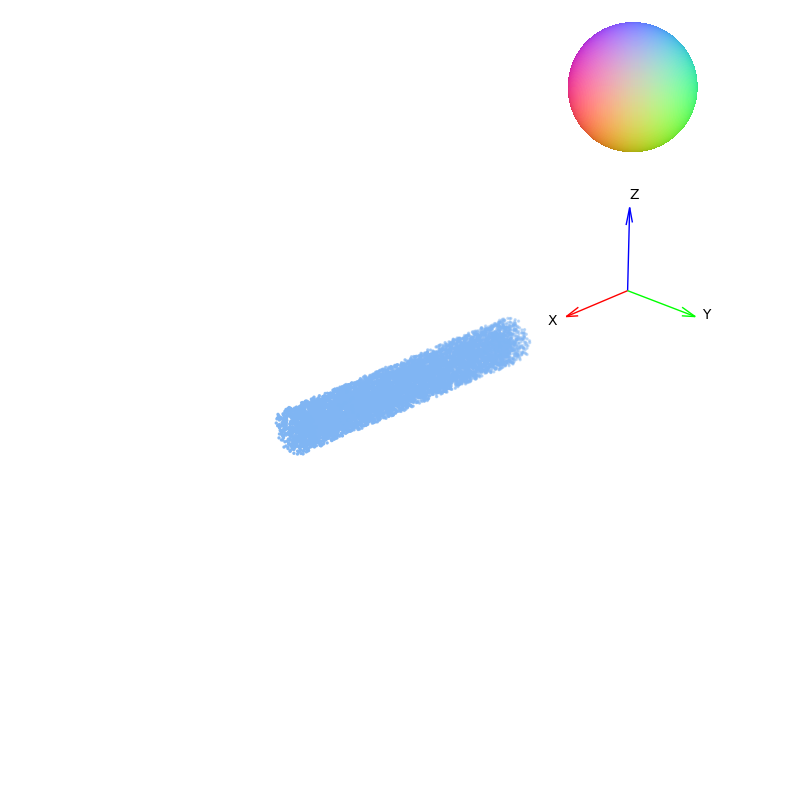

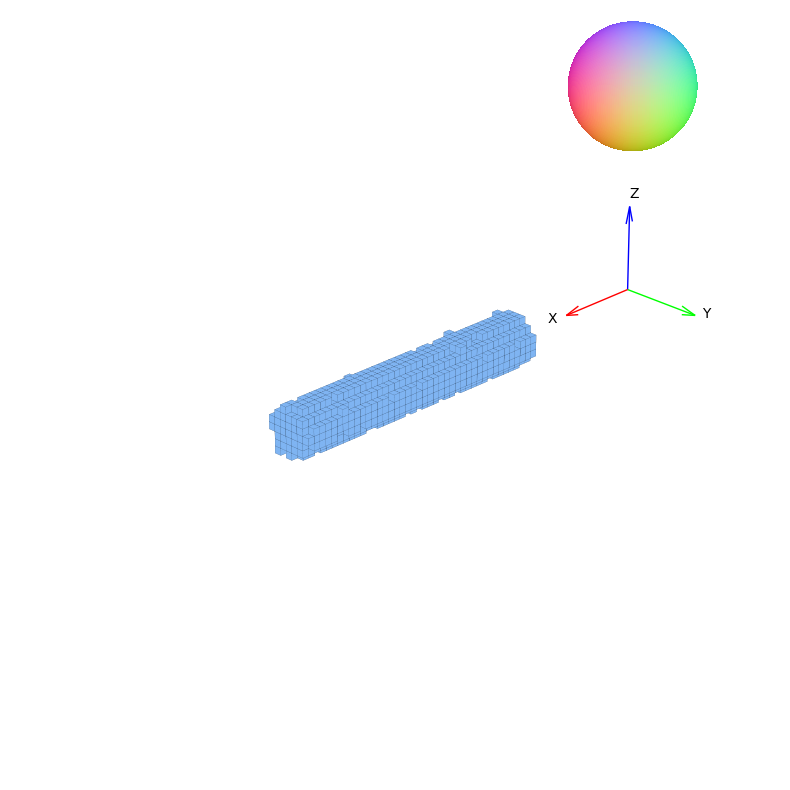

Sweeping params:  50%|██████████████████████████▌                          | 1/2 [00:07<00:07,  7.40s/it]

(80,)
[[ 3.77866383e-10  9.84807753e-01  1.73648178e-01]
 [ 5.14618790e-10  9.84807753e-01  1.73648178e-01]
 [ 3.74799300e-10  9.84807753e-01  1.73648178e-01]
 ...
 [ 1.00388313e-10  9.84807753e-01  1.73648178e-01]
 [-3.58434698e-10  9.84807753e-01  1.73648178e-01]
 [ 7.58258464e-11  9.84807753e-01  1.73648178e-01]]


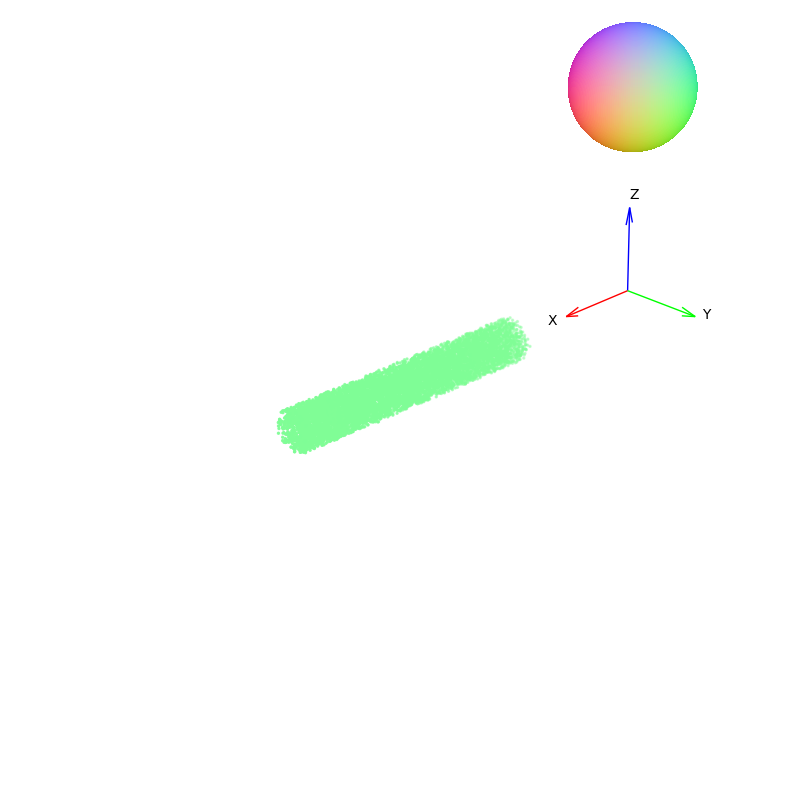

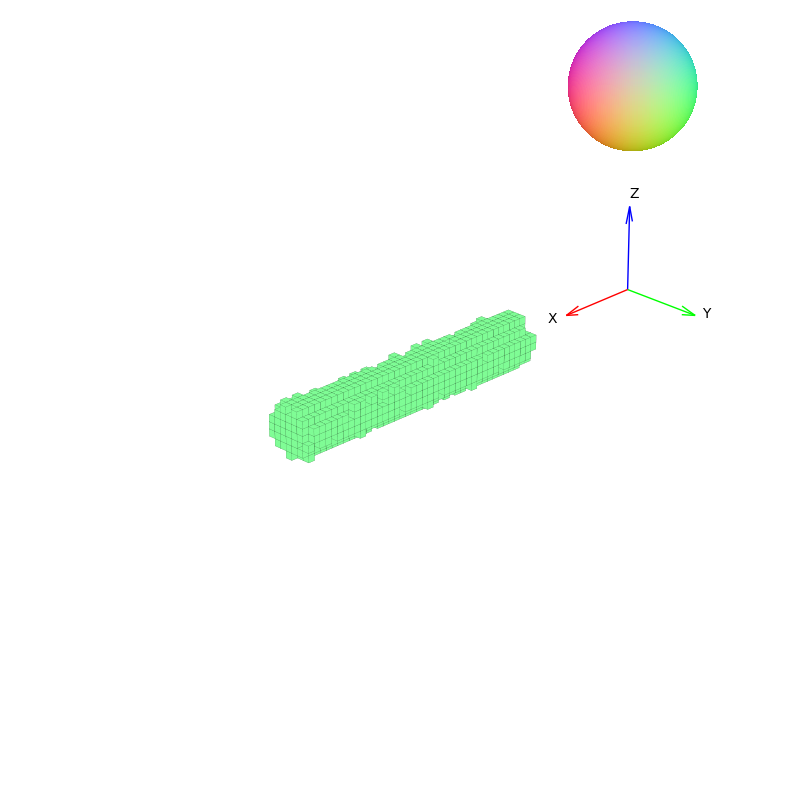

Sweeping params: 100%|█████████████████████████████████████████████████████| 2/2 [00:14<00:00,  7.42s/it]


In [42]:
# Make list of all tuples for parameter and value to be swept over
sweep_keys = args['sweep_params']
sweep_vals = args['sweep_params_values']
combinations = list(product(*sweep_vals))

# Create folder for these argument parameters
params_ID = args['params_ID']
folder_string = f'paramsID-{params_ID}'
for sweep_key in sweep_keys:
    folder_string = folder_string + '_' + sweep_key
sweepPath = savePath.joinpath(folder_string)
sweepPath.mkdir(exist_ok=True)

# # Save arguments dictionary in the above folder
# json_ready_args = {
#     k: v.tolist() if isinstance(v, np.ndarray) else v
#     for k, v in args.items()
# }
# with sweepPath.joinpath('args.json').open('w') as f:
#     json.dump(json_ready_args, f)

for combo in tqdm(combinations[::1], desc="Sweeping params"):
    print(combo)
    sweep_args = args.copy()
    for k, v in zip(sweep_keys, combo):
        sweep_args[k] = v

    # Create fibril unique for each combo
    backbone_coords, backbone_axs, backbone_css, fibril_coords, fibril_shell_coords = gen_scat_coords_flexcyl(
        sweep_args['fibril_density'],
        sweep_args['fibril_length'],
        sweep_args['fibril_diam'],
        sweep_args['fibril_flex'],
        sweep_args['fibril_shell_density'],
        sweep_args['fibril_shell_length']
    )
    # print('test1')

    # Rotate fibril about 'y' fibril tilt
    # Rotate fibril about Z just to move psi closer away from the 0/360 weirdness along X
    rotation = R.from_euler('yz', [sweep_args['fibril_tilt'], 0], degrees=True)
    rotated_bb = rotation.apply(backbone_coords)
    rotated_fibril = rotation.apply(fibril_coords)
    rotated_bb_axs = rotation.apply(backbone_axs)
    rotated_bb_css_1 = rotation.apply(backbone_css[:, 0, :])
    rotated_bb_css_2 = rotation.apply(backbone_css[:, 1, :])
    rotated_bb_css = np.stack((rotated_bb_css_1, rotated_bb_css_2))

    # Set molecular orientations and strengths
    fibril_vectors = mol_orient_vectors(
        sweep_args['molecular_orientation'], rotated_bb, rotated_bb_axs, rotated_bb_css, rotated_fibril, sweep_args['set_theta'])
    fibril_RGB_values = (fibril_vectors+1)/2

    print(fibril_vectors)
    
    if fibril_shell_coords.shape == (0,):
        # Make PointCloud
        pcd = o3d.geometry.PointCloud()
        pcd.points.extend(rotated_fibril)
        pcd.colors.extend(fibril_RGB_values)
    else:
        pass
        # rotated_fibril_shell = rotation.apply(fibril_shell_coords)
        
        # fibril_shell_ZYrots = mol_orient(
        #     sweep_args['molecular_orientation'], rotated_bb, rotated_bb_axs, rotated_bb_css, rotated_fibril_shell, sweep_args['set_theta'])
        # fibril_shell_RGB_values = np.array([
        #     np.sin(np.deg2rad(fibril_shell_ZYrots[:,0]/2))**2,  # psi, inverse: np.rad2deg(np.arcsin(np.sqrt(fibril_RGB_values[:,0])))
        #     np.sin(np.deg2rad(fibril_shell_ZYrots[:,1]/2))**2,  # theta, inverse: np.rad2deg(np.arcsin(np.sqrt(fibril_RGB_values[:,1])))
        #     np.full(fibril_shell_ZYrots[:, 0].shape, sweep_args['shell_S'])
        # ]).T
    
        # pcd = o3d.geometry.PointCloud()
        # pcd.points.extend(np.vstack((rotated_fibril, rotated_fibril_shell)))
        # pcd.colors.extend(np.vstack((fibril_RGB_values, fibril_shell_RGB_values)))
    
    # Voxelize PointCloud
    vg = o3d.geometry.VoxelGrid.create_from_point_cloud(pcd, voxel_size=sweep_args["PhysSize_angstroms_per_voxel"])

    # Save VoxelGrid and Visualizations

    label = "_".join([f"{k}-{v}" for k, v in zip(sweep_keys, combo)])

    # Save
    # o3d.io.write_voxel_grid(str(sweepPath.joinpath(f'{label}.ply')), vg)
    plot_pointcloud_with_legend(pcd, background='white', show=True, 
                                # axes_origin=(-160,-200,0), sphere_origin=(-160,-200,120), 
                                axes_origin=(-220,0,0), sphere_origin=(-220,0,50), zoom=1.4, 
                                axes_length=120, elev=25, azim=45, hide_axes=True,  
                                savePath=sweepPath.joinpath(f'{label}_pcd.png'))
    plot_voxelgrid_with_legend(vg, background='white', show=True, 
                               # axes_origin=(-160,-200,0), sphere_origin=(-160,-200,120), 
                               axes_origin=(-220,0,0), sphere_origin=(-220,0,50), zoom=1.4,
                               axes_length=120, elev=25, azim=45, hide_axes=True,  
                               savePath=sweepPath.joinpath(f'{label}_vg.png'))
    
    # # View during testing
    # plot_pointcloud_with_legend(pcd, background='white', show=True, 
    #                             axes_origin=(-100,-100,0), sphere_origin=(-100,-100,50), zoom=1.4, 
    #                             axes_length=120, elev=25, azim=45, hide_axes=True)
    # plot_voxelgrid_with_legend(vg, background='white', show=True, 
    #                            axes_origin=(-100,-100,0), sphere_origin=(-100,-100,50), zoom=1.4,
    #                            axes_length=120, elev=25, azim=45, hide_axes=True)
    
    plt.close('all')

In [28]:
sweepPath

PosixPath('/Users/andrew/Library/CloudStorage/OneDrive-UCB-O365/research/data_analysis/rsoxs_suite/morph_gen/simple_fibril_open3d_outputs/paramsID-for_images_set_theta')

In [ ]:
# pcd = o3d.geometry.PointCloud()
# pcd.points.extend(np.array([[0,0,0], [100,100,100]]))
# pcd.colors.extend(np.array([[1,1,1], [1,1,1]]))

# for elev in tqdm([-60,-45,0,45,60]):
#     for azim in [0,45,90,135,180,225,270,315]:
#         print(elev,azim)
#         plot_pointcloud_with_legend(pcd, background='white', show=True, zoom=1, 
#                                     axes_origin=(0, 0, 0), 
#                                     sphere_origin=(40,40,50), 
#                                     axes_length=35, 
#                                     savePath=sphere_legends_path.joinpath(f'elev{elev}_azim{azim}.png'),
#                                     elev=elev, azim=azim, hide_axes=True)

In [ ]:
plot

## Arrange fibrils

In [ ]:
rotated_fibril.shape

In [ ]:
points = np.array([[1,1,1],
                   [2,2,2]])
colors = np.array([[1,1,1,1],
                   [2,2,2,2]])

In [ ]:
pcd = o3d.geometry.PointCloud()
pcd.points.extend(points)
pcd.colors.extend(colors)

In [ ]:
pcd.normals

In [ ]:
np.asarray(pcd.colors)

In [ ]:
pcd

In [ ]:
o3d.visualization.EV.set(pc)

## Use open3D to voxelize point cloud

In [ ]:
voxel_grid = o3d.geometry.VoxelGrid.create_from_point_cloud(pc, voxel_size=10)
voxel_grid

In [ ]:
# Convert voxel grid to list of voxels, with grid index & color

voxels = vg.get_voxels()  # returns list of voxels
indices = np.stack(list(vx.grid_index for vx in voxels))
colors = np.stack(list(vx.color for vx in voxels))

voxels

In [ ]:
indices.max()

In [ ]:
# visualize, will need to restart kernel after :O
o3d.visualization.draw_geometries([vg])

## Save open3d voxelgrids